# Centralized Model (Baseline)

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from train import task
from exploration import exploration_utils
import centralized_utils

## Data

In [2]:
from datasets import load_dataset

ds_a = load_dataset("exalsius/NIH-Chest-XRay-Federated", "hospital_a")
ds_b = load_dataset("exalsius/NIH-Chest-XRay-Federated", "hospital_b")
ds_c = load_dataset("exalsius/NIH-Chest-XRay-Federated", "hospital_c")

C:\Users\sofia\OneDrive\Documents\School\CS 535\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd

In [4]:
data_dir_a = "../../data/hospital_a/"
data_dir_b = "../../data/hospital_b/"
data_dir_c = "../../data/hospital_c/"

train_filenames = 'train-*.parquet'
eval_filenames = 'eval-*.parquet'

data_paths = [data_dir_a, data_dir_b, data_dir_c]

df_train_combined = centralized_utils.get_hospitals_df(data_paths, train_filenames)
df_eval_combined = centralized_utils.get_hospitals_df(data_paths, eval_filenames)

### Double checking size is correct

In [5]:
# Get train/val DataFrames for each hospital
data_dir_a = '../../data/hospital_a/'
train_filenames = 'train-*.parquet'
eval_filenames = 'eval-*.parquet'

df_train_a, df_eval_a, df_combined_a = exploration_utils.get_hospital_dfs(data_dir_a, train_filenames, eval_filenames)
len(df_train_a), len(df_eval_a)

data_dir_b = '../../data/hospital_b/'

df_train_b, df_eval_b, df_combined_b = exploration_utils.get_hospital_dfs(data_dir_b, train_filenames, eval_filenames)
len(df_train_b), len(df_eval_b)

data_dir_c = '../../data/hospital_c/'

df_train_c, df_eval_c, df_combined_c = exploration_utils.get_hospital_dfs(data_dir_c, train_filenames, eval_filenames)
len(df_train_c), len(df_eval_c);

In [6]:
print(len(df_train_combined) == len(df_train_a) + len(df_train_b) + len(df_train_c))

train_info = {
    '# of Examples in Hospital A': [f'{len(df_train_a):,}'],
    '# of Examples in Hospital B': [f'{len(df_train_b):,}'],
    '# of Examples in Hospital C': [f'{len(df_train_c):,}'],
    'Total Number of Examples': [f'{len(df_train_combined):,}']
}
train_info = pd.DataFrame.from_dict(train_info, orient='index', columns=['Count'])
train_info

True


,Count
# of Examples in Hospital A,"2,380"
# of Examples in Hospital B,"2,322"
# of Examples in Hospital C,"2,363"
Total Number of Examples,"7,065"


In [7]:
print(len(df_eval_combined) == len(df_eval_a) + len(df_eval_b) + len(df_eval_c))

eval_info = {
    '# of Examples in Hospital A': [f'{len(df_eval_a):,}'],
    '# of Examples in Hospital B': [f'{len(df_eval_b):,}'],
    '# of Examples in Hospital C': [f'{len(df_eval_c):,}'],
    'Total Number of Examples': [f'{len(df_eval_combined):,}']
}
eval_info = pd.DataFrame.from_dict(eval_info, orient='index', columns=['Count'])
eval_info

True


,Count
# of Examples in Hospital A,310
# of Examples in Hospital B,306
# of Examples in Hospital C,312
Total Number of Examples,928


### Class Imbalance

In [8]:
label_distribution = df_train_combined['label'].explode().value_counts().reset_index()
label_distribution.columns = ['Pathology Label', 'Frequency']
label_distribution['Percentage (%)'] = (label_distribution['Frequency'] / len(df_train_combined) * 100).map(lambda x: f'{x:.2f}')
label_distribution

,Pathology Label,Frequency,Percentage (%)
0,No Finding,3862,54.66
1,Infiltration,1299,18.39
2,Effusion,746,10.56
3,Atelectasis,719,10.18
4,Nodule,386,5.46
5,Mass,352,4.98
6,Pneumothorax,340,4.81
7,Consolidation,269,3.81
8,Pleural_Thickening,216,3.06
9,Cardiomegaly,155,2.19


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

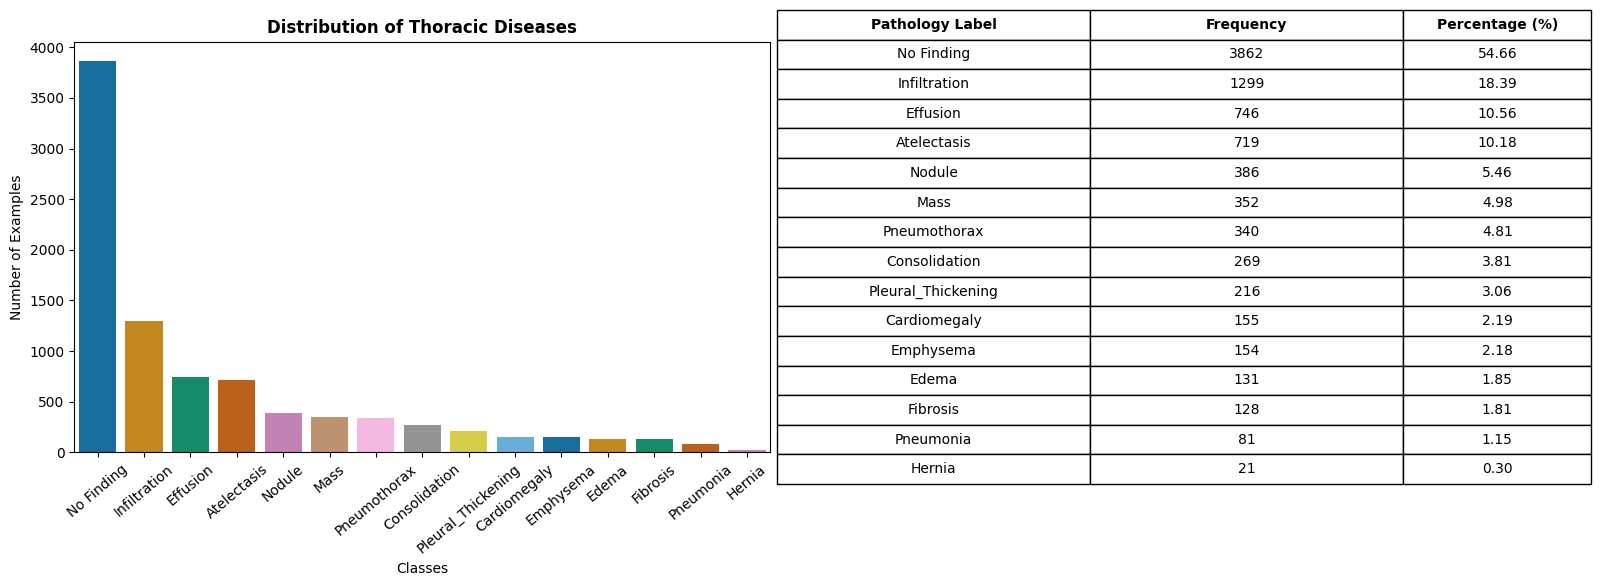

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=label_distribution, x='Pathology Label', y='Frequency', hue='Pathology Label', ax=ax[0], palette='colorblind')
ax[0].set_title('Distribution of Thoracic Diseases').set_weight('bold')
ax[0].set_xlabel('Classes')
ax[0].set_ylabel('Number of Examples')
ax[0].tick_params(axis='x', rotation=40)

table = ax[1].table(cellText=label_distribution.values, cellLoc='center', 
            colLabels=label_distribution.columns, loc='center', colWidths=[0.5, 0.5, 0.3])
table.scale(0.9 ,2)
table[0, 0].get_text().set_weight('bold')
table[0, 1].get_text().set_weight('bold')
table[0, 2].get_text().set_weight('bold')
ax[1].axis('off')
plt.tight_layout()
plt.show();

### Data Visualization (Preprocessing vs. No-preprocessing)

In [11]:
from torchvision import models

Desnet121 requires the following data preprocessing:

In [12]:
weights = models.DenseNet121_Weights.DEFAULT
preprocess_transform = weights.transforms()
preprocess_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [13]:
train_preprocessed = task.XrayDataset(df_train_combined, transform=preprocess_transform)
train_not_preprocessed = task.XrayDataset(df_train_combined, transform=None)

In [14]:
pre_img, pre_label = train_preprocessed[4]
not_img, not_label = train_not_preprocessed[4]

#### Preprocessed

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1345534].


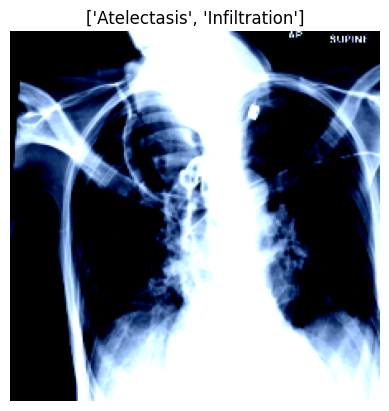

In [15]:
centralized_utils.show_xray(pre_img.permute(1, 2, 0), pre_label)

#### Not Preprocessed

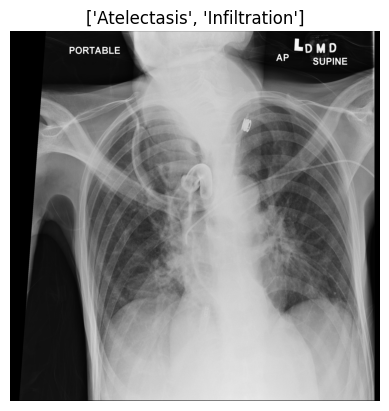

In [16]:
centralized_utils.show_xray(not_img, not_label)

### Weights

In [17]:
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import torch

In [18]:
unique_labels = set(label for labels in df_train_combined['label'] for label in labels)
print(unique_labels)

{'Edema', 'Atelectasis', 'Emphysema', 'Hernia', 'Fibrosis', 'Mass', 'Pneumonia', 'Consolidation', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Pleural_Thickening', 'Nodule', 'Pneumothorax', 'No Finding'}


In [19]:
df_train_combined['label'] = df_train_combined['label'].apply(lambda x: [] if 'No Finding' in x else x)

In [20]:
unique_labels = set(label for labels in df_train_combined['label'] for label in labels)
print(unique_labels) # No Finding not present

{'Edema', 'Atelectasis', 'Emphysema', 'Hernia', 'Fibrosis', 'Mass', 'Pneumonia', 'Consolidation', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Pleural_Thickening', 'Nodule', 'Pneumothorax'}


In [21]:
mlb = MultiLabelBinarizer(classes=task.DISEASE_LABELS)
y_np = mlb.fit_transform(df_train_combined['label'])

In [22]:
# Double Checking one-hot encoding is consistent with DISEASE_LABELS
np.array_equal(mlb.classes_, task.DISEASE_LABELS)

True

In [23]:
y = torch.tensor(y_np, dtype=torch.float32)

In [24]:
pos_weights, neg_weights = centralized_utils.calculate_weights(y)
pos_weights, neg_weights

(tensor([  9.8261,  45.5806,   9.4705,   5.4388,  20.0710,  18.3031,  87.2222,
          20.7794,  26.2639,  53.9313,  45.8766,  55.1953,  32.7083, 336.4286]),
 tensor([1.1133, 1.0224, 1.1181, 1.2253, 1.0524, 1.0578, 1.0116, 1.0506, 1.0396,
         1.0189, 1.0223, 1.0185, 1.0315, 1.0030]))

In [25]:
pos_weights = centralized_utils.calculate_pos_weights(y)
pos_weights

tensor([ 8.8261, 44.5806,  8.4705,  4.4388, 19.0710, 17.3031, 50.0000, 19.7794,
        25.2639, 50.0000, 44.8766, 50.0000, 31.7083, 50.0000])

## Model

#### New Loss Function - Weighted Binary Cross Entropy Loss Function

In [26]:
def weighted_bce_loss(p, y, pos_weights, neg_weights, epsilon=1e-7):
    L = -(pos_weights * y * torch.log(p + epsilon) + neg_weights * (1 - y) * torch.log(1 - p + epsilon))
    return L.mean()

In [27]:
import torch
import time

In [28]:
device = 'cpu'
if torch.cuda.is_available():
    device = torch.device('cuda:0')
print('Running on', device)

Running on cuda:0


In [29]:
n_classes = 14
densenet121 = centralized_utils.DenseNet121(n_classes, device=device)
densenet121

DenseNet121(
  (densenet121): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mome

## Training

In [30]:
from torch.utils.data import DataLoader

In [31]:
n_epochs = 15
batch_size = 32
learning_rate = 0.0001

n_classes = 14
densenet121 = centralized_utils.DenseNet121(n_classes, device=device)
pos_weights = pos_weights.to(device)

train_dataset = task.XrayDataset(df_train_combined, transform=preprocess_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
total_train_loss, training_time, peak_memory_usage = centralized_utils.train(densenet121, train_loader, device, n_epochs, pos_weights, learning_rate);

Epoch 1/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [03:14<00:00,  1.13it/s]


Epoch 1 | average loss: 1.1136 | time: 194.89s


Epoch 2/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [03:19<00:00,  1.11it/s]


Epoch 2 | average loss: 0.9215 | time: 199.69s


Epoch 3/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [03:11<00:00,  1.15it/s]


...

Epoch 6/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [03:26<00:00,  1.07it/s]


Epoch 6 | average loss: 0.3541 | time: 206.63s


Epoch 7/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [03:27<00:00,  1.06it/s]


Epoch 7 | average loss: 0.2811 | time: 207.66s


Epoch 8/15:   5%|█████▌                                                                                                         | 11/221 [00:10<03:31,  1.01s/it]

## Evaluation

### Training Loss Curve

In [ ]:
centralized_utils.plot_loss(total_train_loss)

### Metrics

In [ ]:
def evaluate(model, test_loader, device, threshold=0.5):
    """
    Evaluates model using Jaccard, F1, Recall, Precision, ROC-AUC, Per-class ROC-AUC.
    """
    actual = []
    pred = []
    probs = []
    
    model.eval()
    pbar = tqdm(test_loader, desc=f"Evaluating")
    for (images, labels) in pbar:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            logits = model(images)

            probs = torch.sigmoid(logits).cpu().numpy()

            y_pred = (probs > threshold).int().cpu().numpy()
            y_actual = labels.cpu().numpy()
    
            actual.append(y_actual)
            pred.append(y_pred)
            probs.append(probs)
    actual = np.vstack(actual)
    pred = np.vstack(pred)
    probs = np.vstack(probs)
            
    jaccard = jaccard_score(actual, pred, average='samples', zero_division=0)
    per_class_accuracy = (pred == actual).mean(axis=0) * 100
    per_class_accuracy_dict = {
        disease: acc for disease, acc in zip(task.DISEASE_LABELS, per_class_accuracy)
    }
    f1 = f1_score(actual, pred, average='macro', zero_division=0)
    per_class_f1 = f1_score(actual, pred, average='None', zero_division=0)
    per_class_f1_dict = {
        disease: f1 for disease, f1 in zip(task.DISEASE_LABELS, per_class_f1)
    }
    recall = recall_score(actual, pred, average='macro', zero_division=0)
    precision = precision_score(actual, pred, average='macro', zero_division=0)
    fpr, tpr, thresholds = roc_curve(actual, probs)
    roc_auc = roc_auc_score(actual, probs, average='macro')
    per_class_auc = roc_auc_score(actual, probs, average=None)
    per_class_auc_dict = {
        disease: auc for disease, auc in zip(task.DISEASE_LABELS, per_class_auc)
    }
    aucpr = average_precision_score(actual, probs, average='macro', zero_division=0)
    per_class_aucpr = average_precision_score(actual, probs, average=None, zero_division=0)
    per_class_aucpr_dict = {
        disease: aucpr for disease, aucpr in zip(task.DISEASE_LABELS, per_class_aucpr)
    }
    
    results = {
        'Jaccard Similarity': jaccard,
        'per_class_acc': per_class_accuracy_dict,
        'F1_score': f1, 
        'per_class_f1': per_class_f1_dict,
        'Recall': recall,
        'Precision': precision,
        'roc_curve': [fpr, tpr, thresholds],
        'roc_auc': roc_auc,
        'per_class_auc': per_class_auc_dict,
        'aucpr_curve': aucpr,
        'per_class_aucpr': per_class_aucpr_dict
    }
    return results

In [ ]:
eval_dataset = task.XrayDataset(df_eval_combined, transform=preprocess_transform)
eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

results = centralized_utils.evaluate(densenet121, eval_loader, device);

In [ ]:
results = pd.DataFrame([results])
results

In [ ]:
per_class_auc = results['per_class_auc'][0]

for key, val in per_class_auc.items():
    print(f'{key:20s} {val:4f}')

In [ ]:
per_class_acc = results['per_class_acc'][0]

for key, val in per_class_acc.items():
    print(f'{key:20s} {val:4f}%')